In [379]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

## ****Функции****

In [380]:
def _month_dt(x):
    if pd.isna(x):
        return pd.NaT
    if hasattr(x, 'start_time'):
        d = pd.to_datetime(x.start_time)
    elif isinstance(x, str) and '/' in x:
        d = pd.to_datetime(x.split('/')[0].strip(), errors='coerce')
    else:
        d = pd.to_datetime(x, errors='coerce')
    if pd.isna(d):
        return pd.NaT
    return pd.Timestamp(d.year, d.month, 1)

def apply_infl_deflate(df):
    out = df.copy()
    out['month_dt'] = out['month'].apply(_month_dt)

    out = out.merge(infl_map, on='month_dt', how='left', suffixes=('', '_infl'))

    if 'deflator_to_base' not in out.columns:
        if 'deflator_to_base_infl' in out.columns:
            out['deflator_to_base'] = out['deflator_to_base_infl']
        else:
            raise KeyError('deflator_to_base')

    if 'deflator_to_base_infl' in out.columns:
        out['deflator_to_base'] = out['deflator_to_base'].astype(float)
        out['deflator_to_base_infl'] = out['deflator_to_base_infl'].astype(float)
        out['deflator_to_base'] = out['deflator_to_base'].fillna(out['deflator_to_base_infl'])
        out = out.drop(columns=['deflator_to_base_infl'])

    out['deflator_to_base'] = out['deflator_to_base'].ffill().bfill()

    if 'price' in out.columns:
        out['price'] = out['price'].astype(float) * out['deflator_to_base'].astype(float)

    for c in list(out.columns):
        lc = c.lower()
        if lc.endswith('_cost') or lc.endswith('_amount') or lc in ['amount', 'cost', 'penalty', 'amount_base', 'order_amount']:
            out[c] = out[c].astype(float) * out['deflator_to_base'].astype(float)

    return out

In [381]:
def boot_ci(arr, seed=1, n=20000):
    arr = np.array(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    rng = np.random.default_rng(seed)
    sims = rng.choice(arr, size=n, replace=True)
    return {
        'mean': float(sims.mean()),
        'p2_5': float(np.quantile(sims, 0.025)),
        'p97_5': float(np.quantile(sims, 0.975)),
    }

def calculate_nominal_reserves_for_date(current_date, current_product_id):
    real_inv = total_daily_frame.loc[
        (total_daily_frame['date'] == current_date) &
        (total_daily_frame['product_id'] == current_product_id),
        'real_reserves'
    ].iloc[0]

    orders_in_transit = od_cat[
        (od_cat['product_id'] == current_product_id) &
        (od_cat['order_date'] <= current_date) &
        ((od_cat['delivery_date'] > current_date) | (od_cat['delivery_date'].isna()))
    ]

    transit_qty = orders_in_transit['qty'].sum() if not orders_in_transit.empty else 0
    return real_inv + transit_qty

def sample_phi_lt(product_id, rng, min_n=5):
    ph = phi_lists.get(product_id, [])
    lt = lt_m_list.get(product_id, [])

    if len(ph) < min_n:
        ph = phi_pool_all
    if len(lt) < min_n:
        lt = lt_pool_all

    phi = float(rng.choice(ph))
    L = int(rng.choice(lt))
    return phi, L

def build_D_pools(df):
    tmp = df[['month', 'D']].copy()
    tmp['woy'] = tmp['month'].dt.start_time.dt.isocalendar().week.astype(int)
    return tmp.groupby('woy')['D'].apply(list).to_dict()

def once_simulation_trace(df, s, S, rng_seed, D_pool=None, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    rng = np.random.default_rng(int(rng_seed))

    df = df.sort_values('month').reset_index(drop=True)
    R = float(df.loc[0, 'R_beg'])

    D_pools = None
    if d_mode == 'seasonal':
        tmp = df[['month', 'D']].copy()
        tmp['woy'] = tmp['month'].dt.start_time.dt.isocalendar().week.astype(int)
        D_pools = tmp.groupby('woy')['D'].apply(list).to_dict()

    pipeline = {}
    rows = []

    total_cost_sum = 0.0
    n_orders = 0
    shortage_periods = 0
    sum_R_plus = 0.0
    sum_R_minus = 0.0

    n = len(df)

    for t in range(n):
        row = df.loc[t]

        A_sim = float(pipeline.pop(t, 0.0))
        R = R + A_sim

        OO = float(sum(pipeline.values()))
        RN = R + OO

        if RN <= s:
            q = float(S - RN)
            if q < 0:
                q = 0.0
        else:
            q = 0.0

        phi_used = np.nan
        L_used = np.nan

        if q > 0:
            n_orders += 1
            phi_used, L_used = sample_phi_lt_cat(rng)
            arrival_t = t + int(L_used)
            pipeline[arrival_t] = pipeline.get(arrival_t, 0.0) + q * float(phi_used)

        # спрос
        if d_mode == 'actual':
            D = float(row['D'])
        elif d_mode == 'forecast':
            D = float(row[demand_col])
        elif d_mode == 'seasonal':
            woy = int(row['month'].start_time.isocalendar().week)
            pool = D_pools.get(woy, D_pool)
            D = float(rng.choice(pool))
        else:
            D = float(rng.choice(D_pool))

        R = R - D

        R_plus = R if R > 0 else 0.0
        R_minus = -R if R < 0 else 0.0

        buy_cost = float(row['Price']) * q
        hold_cost = float(row['res_cost']) * R_plus
        def_cost = float(row['def_cost']) * R_minus
        total_cost_t = buy_cost + hold_cost + def_cost

        total_cost_sum += total_cost_t

        sum_R_plus += R_plus
        sum_R_minus += R_minus
        if R_minus > 0:
            shortage_periods += 1

        rows.append({
            'month': row['month'],
            't': t,
            'A_sim': A_sim,
            'OO': OO,
            'RN': RN,
            'q': q,
            'phi': phi_used,
            'L': L_used,
            'D': D,
            'R_end': R,
            'R_plus_end': R_plus,
            'R_minus_end': R_minus,
            'buy_cost': buy_cost,
            'hold_cost': hold_cost,
            'def_cost': def_cost,
            'total_cost': total_cost_t
        })

    trace = pd.DataFrame(rows)

    summary = {
        'total_cost': float(total_cost_sum),
        'n_orders': int(n_orders),
        'shortage_share': float(shortage_periods / n) if n > 0 else np.nan,
        'R_plus_avg': float(sum_R_plus / n) if n > 0 else np.nan,
        'R_minus_avg': float(sum_R_minus / n) if n > 0 else np.nan
    }

    return trace, summary

def once_simulation(df, s, S, rng_seed, D_pool=None, d_mode='bootstrap', demand_col='fc_ewm_t1', D_pools=None):
    rng = np.random.default_rng(int(rng_seed))

    df = df.sort_values('month').reset_index(drop=True)
    R = float(df.loc[0, 'R_beg'])

    pipeline = {}
    total_cost = 0.0

    n_orders = 0
    shortage_periods = 0
    sum_R_plus = 0.0
    sum_R_minus = 0.0

    n = len(df)

    for t in range(n):
        row = df.loc[t]

        A_sim = float(pipeline.pop(t, 0.0))
        R = R + A_sim

        OO = float(sum(pipeline.values()))
        RN = R + OO

        if RN <= s:
            q = float(S - RN)
            if q < 0:
                q = 0.0
        else:
            q = 0.0

        if q > 0:
            n_orders += 1
            phi, L = sample_phi_lt_cat(rng)
            arrival_t = t + int(L)
            pipeline[arrival_t] = pipeline.get(arrival_t, 0.0) + q * float(phi)

        # спрос
        if d_mode == 'actual':
            D = float(row['D'])
        elif d_mode == 'forecast':
            D = float(row[demand_col])
        elif d_mode == 'seasonal':
            woy = int(row['month'].start_time.isocalendar().week)
            pool = D_pools.get(woy, D_pool)
            D = float(rng.choice(pool))
        else:
            D = float(rng.choice(D_pool))

        R = R - D

        R_plus = R if R > 0 else 0.0
        R_minus = -R if R < 0 else 0.0

        buy_cost = float(row['Price']) * q
        hold_cost = float(row['res_cost']) * R_plus
        def_cost = float(row['def_cost']) * R_minus

        total_cost += buy_cost + hold_cost + def_cost

        sum_R_plus += R_plus
        sum_R_minus += R_minus
        if R_minus > 0:
            shortage_periods += 1

    return {
        'total_cost': total_cost,
        'n_orders': n_orders,
        'shortage_share': shortage_periods / n if n > 0 else np.nan,
        'R_plus_avg': sum_R_plus / n if n > 0 else np.nan,
        'R_minus_avg': sum_R_minus / n if n > 0 else np.nan
    }

def eval_policy(df, s, S, D_pool=None, n_sims=1000, base_seed=1, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    D_pools = None
    if d_mode == 'seasonal':
        tmp = df[['month', 'D']].copy()
        tmp['woy'] = tmp['month'].dt.start_time.dt.isocalendar().week.astype(int)
        D_pools = tmp.groupby('woy')['D'].apply(list).to_dict()

    costs = []
    shorts = []
    orders = []

    for k in range(int(n_sims)):
        res = once_simulation(
            df=df,
            s=float(s),
            S=float(S),
            rng_seed=base_seed + k,
            D_pool=D_pool,
            d_mode=d_mode,
            demand_col=demand_col,
            D_pools=D_pools
        )
        costs.append(res['total_cost'])
        shorts.append(res['shortage_share'])
        orders.append(res['n_orders'])

    return {
        's': float(s),
        'S': float(S),
        'mean_cost': float(np.mean(costs)),
        'meadian_cost': float(np.median(costs)),
        'p95_cost': float(np.quantile(costs, 0.95)),
        'mean_shortage_share': float(np.mean(shorts)),
        'mean_n_orders': float(np.mean(orders)),
    }


def grid_search_s_delta(df, D_pool, s_grid, Delta_grid, n_sims=1000, base_seed=1,
                        d_mode='bootstrap', max_shortage_share=None, demand_col='fc_ewm_t1',
                        objective='mean'):
    best = None
    results = []

    for s in s_grid:
        for Delta in Delta_grid:
            S = float(s + Delta)

            est = eval_policy(
                df=df,
                s=float(s),
                S=S,
                D_pool=D_pool,
                n_sims=n_sims,
                base_seed=base_seed,
                d_mode=d_mode,
                demand_col=demand_col
            )

            est['Delta'] = float(Delta)
            results.append(est)

            if (max_shortage_share is not None) and (est['mean_shortage_share'] > max_shortage_share):
                continue

            key = 'mean_cost' if objective == 'mean' else 'meadian_cost'
            if (best is None) or (est[key] < best[key]):
                best = est

    return best, results

def forecast_by_period(df, s, S, D_pool=None, n_sims=500, base_seed=1, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    df = df.sort_values('month').reset_index(drop=True)
    months = df['month'].tolist()
    n = len(df)

    q_mat = np.zeros((int(n_sims), n), dtype=float)
    buy_mat = np.zeros((int(n_sims), n), dtype=float)
    hold_mat = np.zeros((int(n_sims), n), dtype=float)
    def_mat = np.zeros((int(n_sims), n), dtype=float)
    tot_mat = np.zeros((int(n_sims), n), dtype=float)

    summaries = []

    for k in range(int(n_sims)):
        tr, summ = once_simulation_trace(
            df=df,
            s=float(s),
            S=float(S),
            rng_seed=base_seed + k,
            D_pool=D_pool,
            d_mode=d_mode,
            demand_col=demand_col
        )
        summaries.append(summ)

        q_mat[k, :] = tr['q'].to_numpy(dtype=float)
        buy_mat[k, :] = tr['buy_cost'].to_numpy(dtype=float)
        hold_mat[k, :] = tr['hold_cost'].to_numpy(dtype=float)
        def_mat[k, :] = tr['def_cost'].to_numpy(dtype=float)
        tot_mat[k, :] = tr['total_cost'].to_numpy(dtype=float)

    out = pd.DataFrame({
        'month': months,

        'q_mean': q_mat.mean(axis=0),
        'q_p50': np.quantile(q_mat, 0.50, axis=0),
        'q_p95': np.quantile(q_mat, 0.95, axis=0),

        'buy_cost_mean': buy_mat.mean(axis=0),
        'hold_cost_mean': hold_mat.mean(axis=0),
        'def_cost_mean': def_mat.mean(axis=0),
        'total_cost_mean': tot_mat.mean(axis=0),
        'total_cost_p95_week': np.quantile(tot_mat, 0.95, axis=0),
    })

    overall = {
        'mean_cost': float(np.mean([x['total_cost'] for x in summaries])),
        'p95_cost': float(np.quantile([x['total_cost'] for x in summaries], 0.95)),
        'mean_shortage_share': float(np.mean([x['shortage_share'] for x in summaries])),
        'mean_n_orders': float(np.mean([x['n_orders'] for x in summaries])),
    }

    return overall, out

def baseline_costs(df, buy_mode='amount'):
    if buy_mode == 'amount':
        buy = df['amount_base'].copy()
    else:
        buy = df['Price'] * df['q_base']

    R_plus = df['R_plus_avg']
    R_minus = df['R_minus_avg']

    hold = df['res_cost'] * R_plus
    deff = df['def_cost'] * R_minus

    out = pd.DataFrame({
        'month': df['month'],
        'buy_cost_real': buy,
        'hold_cost_real': hold,
        'def_cost_real': deff,
        'total_cost_real': buy + hold + deff,
        'short_flag_real': (R_minus.astype(float) > 0).astype(int),
        'order_flag_real': (df['q_base'].astype(float) > 0).astype(int),
    })

    metrics = {
        'mean_cost': float(out['total_cost_real'].sum()),
        'p95_cost': float(out['total_cost_real'].sum()),  # baseline не случайный -> одно значение
        'p95_week_cost': float(np.quantile(out['total_cost_real'], 0.95)),
        'mean_shortage_share': float(out['short_flag_real'].mean()),
        'mean_n_orders': float(out['order_flag_real'].sum()),
    }

    return metrics, out

def collect_costs(df, s, S, n_sims, base_seed, D_pool=None, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    costs = []
    for k in range(int(n_sims)):
        res = once_simulation(
            df=df,
            s=float(s),
            S=float(S),
            rng_seed=base_seed + k,
            D_pool=D_pool,
            d_mode=d_mode,
            demand_col=demand_col
        )
        costs.append(res['total_cost'])
    return np.array(costs, dtype=float)

def compare_real_vs_forecast(df_real_week, forecast_week, buy_mode='amount'):
    base_metrics, base_tbl = baseline_costs(df_real_week, buy_mode=buy_mode)

    cmp = base_tbl.merge(forecast_week, on='month', how='left', validate='one_to_one')

    cmp['delta_total_mean'] = cmp['total_cost_mean'] - cmp['total_cost_real']
    cmp['delta_buy_mean'] = cmp['buy_cost_mean'] - cmp['buy_cost_real']
    cmp['delta_hold_mean'] = cmp['hold_cost_mean'] - cmp['hold_cost_real']
    cmp['delta_def_mean'] = cmp['def_cost_mean'] - cmp['def_cost_real']
    cmp['delta'] = cmp['total_cost_mean'] - cmp['total_cost_real']

    metrics = {
        'delta_total': float(cmp['delta'].sum()),
        'delta_mean': float(cmp['delta'].mean()),
        'delta_std': float(cmp['delta'].std()),
        'q95_delta': float(np.quantile(cmp['delta'], 0.95)),
        'q95_pred_week': float(np.quantile(cmp['total_cost_mean'], 0.95)),
        'q95_real_week': float(np.quantile(cmp['total_cost_real'], 0.95)),
    }
    return base_metrics, cmp, metrics

def build_orders_cmp(df_part, split_label):
    model_metrics, forecast_tbl = forecast_by_period(
        df=df_part,
        s=best['s'],
        S=best['S'],
        D_pool=None,
        n_sims=500,
        base_seed=1,
        d_mode=d_mode_use,
        demand_col=demand_col
    )

    # реальные закупки
    real_tbl = df_part[['month', 'q_base', 'amount_base', 'Price']].copy()
    real_tbl['buy_cost_real'] = real_tbl['amount_base']
    real_tbl['buy_cost_real_price'] = real_tbl['Price'] * real_tbl['q_base']  # контроль
    real_tbl['split'] = split_label

    cmp = (real_tbl
        .merge(
            forecast_tbl[['month', 'q_mean', 'q_p50', 'q_p95', 'buy_cost_mean', 'total_cost_mean']],
            on='month',
            how='left',
            validate='one_to_one'
        )
    )

    cmp['q_delta_mean'] = cmp['q_mean'] - cmp['q_base']
    cmp['buy_delta_mean'] = cmp['buy_cost_mean'] - cmp['buy_cost_real']

    return cmp, model_metrics

In [382]:
def once_simulation_rQ(df, r, Q, rng_seed, D_pool=None, d_mode='bootstrap', demand_col='fc_ewm_t1', D_pools=None):
    rng = np.random.default_rng(int(rng_seed))

    df = df.sort_values('month').reset_index(drop=True)
    R = float(df.loc[0, 'R_beg'])

    pipeline = {}
    total_cost = 0.0

    n_orders = 0
    shortage_periods = 0
    sum_R_plus = 0.0
    sum_R_minus = 0.0

    n = len(df)

    for t in range(n):
        row = df.loc[t]

        # приход в начале периода
        A_sim = float(pipeline.pop(t, 0.0))
        R = R + A_sim

        # позиция запаса
        OO = float(sum(pipeline.values()))
        RN = R + OO

        # rQ-правило: если RN <= r, то q = Q, иначе 0
        if RN <= float(r):
            q = float(Q)
        else:
            q = 0.0

        if q > 0:
            n_orders += 1
            phi, L = sample_phi_lt_cat(rng)
            arrival_t = t + int(L)
            pipeline[arrival_t] = pipeline.get(arrival_t, 0.0) + q * float(phi)

        # спрос
        if d_mode == 'actual':
            D = float(row['D'])
        elif d_mode == 'forecast':
            D = float(row[demand_col])
        elif d_mode == 'seasonal':
            woy = int(row['month'].start_time.isocalendar().week)
            pool = D_pools.get(woy, D_pool)
            D = float(rng.choice(pool))
        else:
            D = float(rng.choice(D_pool))

        # баланс
        R = R - D

        R_plus = R if R > 0 else 0.0
        R_minus = -R if R < 0 else 0.0

        # издержки периода
        buy_cost = float(row['Price']) * q
        hold_cost = float(row['res_cost']) * R_plus
        def_cost = float(row['def_cost']) * R_minus

        total_cost += buy_cost + hold_cost + def_cost

        sum_R_plus += R_plus
        sum_R_minus += R_minus
        if R_minus > 0:
            shortage_periods += 1

    return {
        'r': float(r),
        'Q': float(Q),
        'total_cost': total_cost,
        'n_orders': n_orders,
        'shortage_share': shortage_periods / n if n > 0 else np.nan,
        'R_plus_avg': sum_R_plus / n if n > 0 else np.nan,
        'R_minus_avg': sum_R_minus / n if n > 0 else np.nan
    }

def once_simulation_trace_rQ(df, r, Q, rng_seed, D_pool=None, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    rng = np.random.default_rng(int(rng_seed))

    df = df.sort_values('month').reset_index(drop=True)
    R = float(df.loc[0, 'R_beg'])

    # сезонные пулы спроса
    D_pools = None
    if d_mode == 'seasonal':
        tmp = df[['month', 'D']].copy()
        tmp['woy'] = tmp['month'].dt.start_time.dt.isocalendar().week.astype(int)
        D_pools = tmp.groupby('woy')['D'].apply(list).to_dict()

    pipeline = {}
    rows = []

    total_cost_sum = 0.0
    n_orders = 0
    shortage_periods = 0
    sum_R_plus = 0.0
    sum_R_minus = 0.0

    n = len(df)

    for t in range(n):
        row = df.loc[t]

        A_sim = float(pipeline.pop(t, 0.0))
        R = R + A_sim

        OO = float(sum(pipeline.values()))
        RN = R + OO

        if RN <= float(r):
            q = float(Q)
        else:
            q = 0.0

        phi_used = np.nan
        L_used = np.nan

        if q > 0:
            n_orders += 1
            phi_used, L_used = sample_phi_lt_cat(rng)
            arrival_t = t + int(L_used)
            pipeline[arrival_t] = pipeline.get(arrival_t, 0.0) + q * float(phi_used)

        if d_mode == 'actual':
            D = float(row['D'])
        elif d_mode == 'forecast':
            D = float(row[demand_col])
        elif d_mode == 'seasonal':
            woy = int(row['month'].start_time.isocalendar().week)
            pool = D_pools.get(woy, D_pool)
            D = float(rng.choice(pool))
        else:
            D = float(rng.choice(D_pool))

        R = R - D

        R_plus = R if R > 0 else 0.0
        R_minus = -R if R < 0 else 0.0

        buy_cost = float(row['Price']) * q
        hold_cost = float(row['res_cost']) * R_plus
        def_cost = float(row['def_cost']) * R_minus
        total_cost_t = buy_cost + hold_cost + def_cost

        total_cost_sum += total_cost_t

        sum_R_plus += R_plus
        sum_R_minus += R_minus
        if R_minus > 0:
            shortage_periods += 1

        rows.append({
            'month': row['month'],
            't': t,
            'A_sim': A_sim,
            'OO': OO,
            'RN': RN,
            'q': q,
            'phi': phi_used,
            'L': L_used,
            'D': D,
            'R_end': R,
            'R_plus_end': R_plus,
            'R_minus_end': R_minus,
            'buy_cost': buy_cost,
            'hold_cost': hold_cost,
            'def_cost': def_cost,
            'total_cost': total_cost_t
        })

    trace = pd.DataFrame(rows)

    summary = {
        'r': float(r),
        'Q': float(Q),
        'total_cost': float(total_cost_sum),
        'n_orders': int(n_orders),
        'shortage_share': float(shortage_periods / n) if n > 0 else np.nan,
        'R_plus_avg': float(sum_R_plus / n) if n > 0 else np.nan,
        'R_minus_avg': float(sum_R_minus / n) if n > 0 else np.nan
    }

    return trace, summary

def eval_policy_rQ(df, r, Q, D_pool=None, n_sims=1000, base_seed=1, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    D_pools = None
    if d_mode == 'seasonal':
        tmp = df[['month', 'D']].copy()
        tmp['woy'] = tmp['month'].dt.start_time.dt.isocalendar().week.astype(int)
        D_pools = tmp.groupby('woy')['D'].apply(list).to_dict()

    costs = []
    shorts = []
    orders = []

    for k in range(int(n_sims)):
        res = once_simulation_rQ(
            df=df,
            r=float(r),
            Q=float(Q),
            rng_seed=base_seed + k,
            D_pool=D_pool,
            d_mode=d_mode,
            demand_col=demand_col,
            D_pools=D_pools
        )
        costs.append(res['total_cost'])
        shorts.append(res['shortage_share'])
        orders.append(res['n_orders'])

    return {
        'r': float(r),
        'Q': float(Q),
        'mean_cost': float(np.mean(costs)),
        'meadian_cost': float(np.median(costs)),
        'p95_cost': float(np.quantile(costs, 0.95)),
        'mean_shortage_share': float(np.mean(shorts)),
        'mean_n_orders': float(np.mean(orders)),
    }

def grid_search_rQ(df, D_pool, r_grid, Q_grid, n_sims=1000, base_seed=1,
                   d_mode='bootstrap', demand_col='fc_ewm_t1',
                   max_shortage_share=None, objective='mean'):
    best = None
    results = []

    key = 'mean_cost' if objective == 'mean' else 'meadian_cost'

    for r in r_grid:
        for Q in Q_grid:
            if float(Q) <= 0:
                continue

            est = eval_policy_rQ(
                df=df,
                r=float(r),
                Q=float(Q),
                D_pool=D_pool,
                n_sims=n_sims,
                base_seed=base_seed,
                d_mode=d_mode,
                demand_col=demand_col
            )

            results.append(est)

            if (max_shortage_share is not None) and (est['mean_shortage_share'] > max_shortage_share):
                continue

            if (best is None) or (est[key] < best[key]):
                best = est

    return best, results

def forecast_by_period_rQ(df, r, Q, D_pool=None, n_sims=500, base_seed=1, d_mode='bootstrap', demand_col='fc_ewm_t1'):
    df = df.sort_values('month').reset_index(drop=True)
    months = df['month'].tolist()
    n = len(df)

    q_mat = np.zeros((int(n_sims), n), dtype=float)
    buy_mat = np.zeros((int(n_sims), n), dtype=float)
    hold_mat = np.zeros((int(n_sims), n), dtype=float)
    def_mat = np.zeros((int(n_sims), n), dtype=float)
    tot_mat = np.zeros((int(n_sims), n), dtype=float)

    summaries = []

    for k in range(int(n_sims)):
        tr, summ = once_simulation_trace_rQ(
            df=df,
            r=float(r),
            Q=float(Q),
            rng_seed=base_seed + k,
            D_pool=D_pool,
            d_mode=d_mode,
            demand_col=demand_col
        )
        summaries.append(summ)

        q_mat[k, :] = tr['q'].to_numpy(dtype=float)
        buy_mat[k, :] = tr['buy_cost'].to_numpy(dtype=float)
        hold_mat[k, :] = tr['hold_cost'].to_numpy(dtype=float)
        def_mat[k, :] = tr['def_cost'].to_numpy(dtype=float)
        tot_mat[k, :] = tr['total_cost'].to_numpy(dtype=float)

    out = pd.DataFrame({
        'month': months,
        'q_mean': q_mat.mean(axis=0),
        'q_p50': np.quantile(q_mat, 0.50, axis=0),
        'q_p95': np.quantile(q_mat, 0.95, axis=0),

        'buy_cost_mean': buy_mat.mean(axis=0),
        'hold_cost_mean': hold_mat.mean(axis=0),
        'def_cost_mean': def_mat.mean(axis=0),
        'total_cost_mean': tot_mat.mean(axis=0),
        'total_cost_p95_week': np.quantile(tot_mat, 0.95, axis=0),
    })

    overall = {
        'r': float(r),
        'Q': float(Q),
        'mean_cost': float(np.mean([x['total_cost'] for x in summaries])),
        'p95_cost': float(np.quantile([x['total_cost'] for x in summaries], 0.95)),
        'mean_shortage_share': float(np.mean([x['shortage_share'] for x in summaries])),
        'mean_n_orders': float(np.mean([x['n_orders'] for x in summaries])),
    }

    return overall, out

def build_orders_cmp_rQ(df_part, split_label):
    model_metrics, forecast_tbl = forecast_by_period_rQ(
        df=df_part,
        r=best_rq['r'],
        Q=best_rq['Q'],
        D_pool=None,
        n_sims=500,
        base_seed=1,
        d_mode=d_mode_use,
        demand_col=demand_col
    )

    real_tbl = df_part[['month', 'q_base', 'amount_base', 'Price']].copy()
    real_tbl['buy_cost_real'] = real_tbl['amount_base']
    real_tbl['buy_cost_real_price'] = real_tbl['Price'] * real_tbl['q_base']  # контроль
    real_tbl['split'] = split_label

    cmp = (real_tbl
        .merge(
            forecast_tbl[['month', 'q_mean', 'q_p50', 'q_p95', 'buy_cost_mean', 'total_cost_mean']],
            on='month',
            how='left',
            validate='one_to_one'
        )
    )

    cmp['q_delta_mean'] = cmp['q_mean'] - cmp['q_base']
    cmp['buy_delta_mean'] = cmp['buy_cost_mean'] - cmp['buy_cost_real']

    return cmp, model_metrics

In [383]:
def fit_model(series, order, sorder, trend='n'):
    try:
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter('always')
            res = SARIMAX(
                series,
                order=order,
                seasonal_order=sorder,
                trend=trend,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

        warn_txt = ' | '.join(sorted(set(str(x.message) for x in w)))
        converged = bool(getattr(res, 'mle_retvals', {}).get('converged', True))
        return {
            'ok': True,
            'aic': float(res.aic),
            'bic': float(res.bic),
            'order': order,
            'seasonal_order': sorder,
            'trend': trend,
            'converged': converged,
            'warn': warn_txt,
            'res': res
        }
    except Exception as e:
        return {
            'ok': False,
            'aic': np.inf,
            'bic': np.inf,
            'order': order,
            'seasonal_order': sorder,
            'trend': trend,
            'converged': False,
            'warn': str(e),
            'res': None
        }

def score_on_holdout(order, sorder):
    res = SARIMAX(
        train,
        order=order,
        seasonal_order=sorder,
        trend='n',
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    fc = res.get_forecast(steps=h).predicted_mean
    mae = float((test - fc).abs().mean())
    rmse = float(np.sqrt(((test - fc)**2).mean()))
    return mae, rmse, res

## **Выгрузка данных**

In [384]:
od = pd.read_csv('/Users/ivanastahov/Downloads/final_orders_train.csv')
cs = pd.read_csv('/Users/ivanastahov/Downloads/final_consumtion_train.csv')

In [385]:
od['order_date'] = pd.to_datetime(od['order_date'])
od['delivery_date'] = pd.to_datetime(od['delivery_date'])
cs['consumtion_date'] = pd.to_datetime(cs['consumtion_date'])

**Инициализация категории**

In [386]:
cat = 1

In [387]:
od_cat = od[od['product_category'] == cat]
od_start_delivery_date = od_cat['delivery_date'].min()

od_cat['order_date'] = pd.to_datetime(od_cat['order_date'])
od_cat['delivery_date'] = pd.to_datetime(od_cat['delivery_date'])
od_cat['lt'] = (od_cat['delivery_date'] - od_cat['order_date']).dt.days
# od_cat

/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/2213285455.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat['order_date'] = pd.to_datetime(od_cat['order_date'])
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/2213285455.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat['delivery_date'] = pd.to_datetime(od_cat['delivery_date'])
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/2213285455.py:6: SettingWithCopyWarning: 
A value is trying to be

In [388]:
cs_cat = cs[cs['product_category'] == cat]
cs_cat = cs_cat[cs['consumtion_date'] >= od_start_delivery_date]
# cs_cat

/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/1708731934.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cs_cat = cs_cat[cs['consumtion_date'] >= od_start_delivery_date]


## ****Создание номинальных и реальных резервов с учётом потребления****

In [389]:
reserves = pd.DataFrame()

od_cat_for_res = od_cat.rename(columns={'delivery_date': 'date', 'valid_delivered_qty': 'real_qty_order', 'qty': 'nominal_qty_order'})
cs_cat_for_res = cs_cat.rename(columns={'consumtion_date': 'date', 'qty': 'use_qty'})

date_min = min(od_cat_for_res['date'].min(), cs_cat_for_res['date'].min())
date_max = max(od_cat_for_res['date'].max(), cs_cat_for_res['date'].max())
all_dates = pd.DataFrame({'date': pd.date_range(start=date_min, end=date_max, freq='D')})

all_products = pd.DataFrame({
    'product_id': pd.concat([od_cat_for_res['product_id'], cs_cat_for_res['product_id']]).dropna().unique()
})
all_dates = (all_dates.assign(key=1)
                     .merge(all_products.assign(key=1), on='key')
                     .drop(columns='key'))

od_daily = (od_cat_for_res
    .groupby(['date', 'product_id'], as_index=False)
    .agg(
        real_qty_order=('real_qty_order', 'sum'),
        nominal_qty_order=('nominal_qty_order', 'sum'),
    )
)
cs_daily = (cs_cat_for_res
    .groupby(['date', 'product_id'], as_index=False)
    .agg(use_qty=('use_qty', 'sum'))
)

od_daily = (all_dates.merge(od_daily, on=['date', 'product_id'], how='left')
                    .fillna({'real_qty_order': 0, 'nominal_qty_order': 0}))
cs_daily = (all_dates.merge(cs_daily, on=['date', 'product_id'], how='left')
                    .fillna({'use_qty': 0}))

total_daily_frame = od_daily.merge(cs_daily, on=['date', 'product_id'], how='left', validate='one_to_one')

total_daily_frame = total_daily_frame.sort_values(['product_id', 'date'])

od_order_daily = (
    od_cat
    .groupby(['order_date', 'product_id'], as_index=False)
    .agg(
        order_qty=('qty', 'sum'),
        order_amount=('amount', 'sum')
    )
)

od_order_daily['order_unit_cost'] = (
    (od_order_daily['order_amount'] / od_order_daily['order_qty'])
    .where(od_order_daily['order_qty'] != 0)
)

od_order_daily = od_order_daily.rename(columns={'order_date': 'date'})

total_daily_frame = (
    total_daily_frame
    .merge(od_order_daily, on=['date', 'product_id'], how='left', validate='one_to_one')
    .fillna({'order_qty': 0, 'order_amount': 0})
)

total_daily_frame['real_reserves'] = (
    total_daily_frame.groupby('product_id')['real_qty_order'].cumsum()
    - total_daily_frame.groupby('product_id')['use_qty'].cumsum()
)
total_daily_frame['nominal_reserves'] = total_daily_frame.apply(
    lambda x: calculate_nominal_reserves_for_date(x['date'], x['product_id']),
    axis=1
)

total_daily_frame['OO'] = total_daily_frame['nominal_reserves'] - total_daily_frame['real_reserves']

total_daily_frame['R_plus'] = total_daily_frame['real_reserves'].clip(lower=0)
total_daily_frame['R_minus'] = (-total_daily_frame['real_reserves']).clip(lower=0)
# total_daily_frame

**График номинальных и реальных резервов**

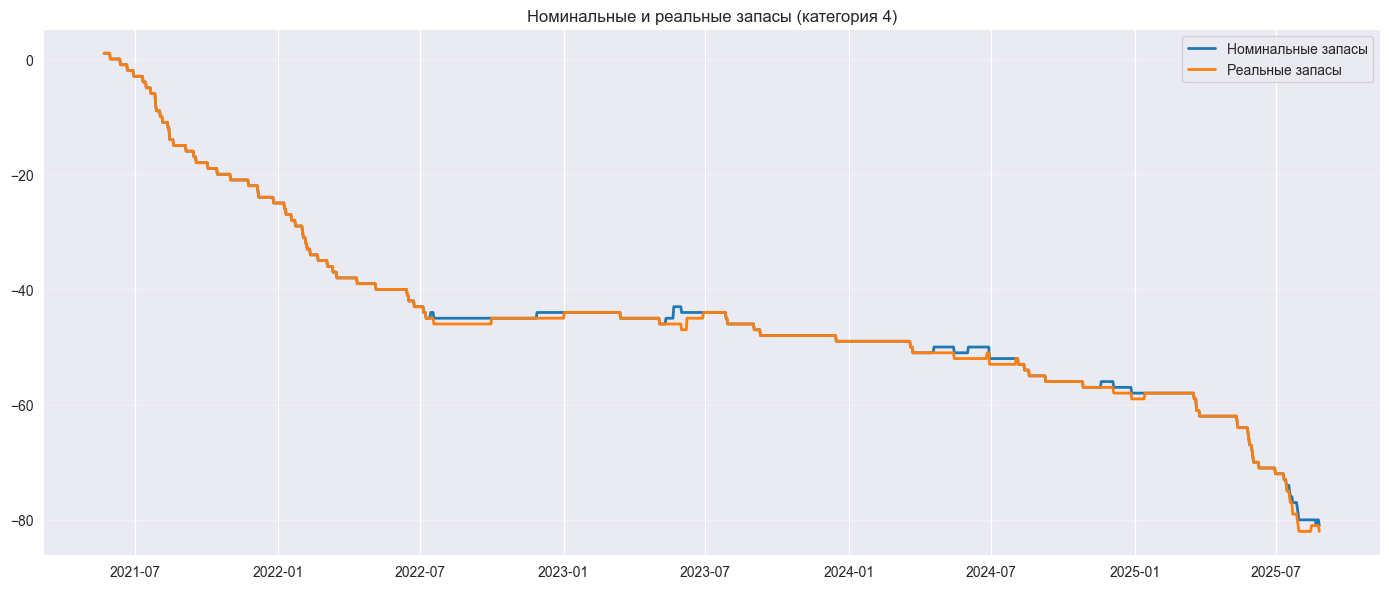

In [390]:
plt.figure(figsize=(14, 6))

total_df = total_daily_frame[['date', 'nominal_reserves', 'real_reserves']]
total_df = total_df.groupby(['date']).agg({'nominal_reserves': 'sum', 'real_reserves': 'sum'}).reset_index()

plt.plot(total_df["date"], total_df["nominal_reserves"],
         label="Номинальные запасы", linewidth=2)

plt.plot(total_df["date"], total_df["real_reserves"],
         label="Реальные запасы", linewidth=2)

plt.title('Номинальные и реальные запасы (категория 4)')
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.show()

## ****Определение возможной доли и времени доставок****

In [391]:
od_cat_train = od_cat[od_cat['order_date'] < '2024-08-01']

od_cat_train['order_date'] = pd.to_datetime(od_cat['order_date'])
od_cat_train['delivery_date'] = pd.to_datetime(od_cat['delivery_date'])
od_cat_train['lt'] = (od_cat_train['delivery_date'] - od_cat_train['order_date']).dt.days

orders_frame = od_cat_train[['product_category', 'product_id', 'qty', 'valid_delivered_qty', 'lt']]
orders_frame['phi'] = orders_frame['valid_delivered_qty'] / orders_frame['qty']

phi_lists = orders_frame.groupby('product_id')['phi'].apply(list).to_dict()
phi_lists = {k: [x for x in v if pd.notna(x)] for k, v in phi_lists.items()}

lt_list = orders_frame.groupby('product_id')['lt'].apply(list).to_dict()
lt_list = {k: [x for x in v if pd.notna(x)] for k, v in lt_list.items()}

/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/3888701169.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat_train['order_date'] = pd.to_datetime(od_cat['order_date'])
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/3888701169.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat_train['delivery_date'] = pd.to_datetime(od_cat['delivery_date'])
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/3888701169.py:5: SettingWithCopyWarning: 
A value is 

## ****Определение стоимости товаров****

In [392]:
od_cat['price'] = od_cat['amount'] / od_cat['qty']

/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/2250256842.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat['price'] = od_cat['amount'] / od_cat['qty']


## ****Разбиение на периоды****

In [393]:
period = 'M'

In [394]:
df = total_daily_frame.copy()
df['month'] = df['date'].dt.to_period(period)
df = df.sort_values(['product_id', 'date'])

df['price'] = df.groupby('product_id')['order_unit_cost'].ffill()

flows = df.groupby(['product_id', 'month'], as_index=False).agg(
    D=('use_qty', 'sum'),                 # спрос за месяц
    A=('real_qty_order', 'sum'),          # фактический приход за месяц
    q_base=('order_qty', 'sum'),          # сколько заказали (baseline) за месяц
    amount_base=('order_amount', 'sum'),  # сумма заказов за месяц
    )

states = df.groupby(['product_id', 'month'], as_index=False).agg(
    R_end=('real_reserves', 'last'),                    # реальный чистый запас на конец месяца
    Nominal_reserves_end=('nominal_reserves', 'last'),  # номинальный запас (реальный + в пути) на конец месяца
    OO_end=('OO', 'last'),                              # объём заказов в пути (on-order) на конец месяца
    R_plus_end=('R_plus', 'last'),                      # положительная часть запаса (наличие на складе) на конец месяца
    R_minus_end=('R_minus', 'last'),                    # дефицит (backorder) на конец месяца
    Price=('price', 'last')                             # цена на конец месяца (последнее известное значение в месяце)
)

monthly = flows.merge(states, on=['product_id', 'month'], how='left', validate='one_to_one')

monthly['R_beg'] = monthly['R_end'] - monthly['A'] + monthly['D']
monthly['R_plus_beg'] = monthly['R_beg'].clip(lower=0)
monthly['R_minus_beg'] = (-monthly['R_beg']).clip(lower=0)

avg_m = (df.groupby(['product_id', 'month'], as_index=False)
    .agg(
        R_plus_avg=('R_plus', 'mean'),
        R_minus_avg=('R_minus', 'mean')
    )
)

monthly = monthly.merge(avg_m, on=['product_id', 'month'], how='left', validate='one_to_one')

cat_df = (monthly.groupby('month', as_index=False)
    .agg(
        D=('D', 'sum'),
        A=('A', 'sum'),
        q_base=('q_base', 'sum'),
        amount_base=('amount_base', 'sum'),
        R_end=('R_end', 'sum'),
        OO_end=('OO_end', 'sum'),
        R_plus_end=('R_plus_end', 'sum'),
        R_minus_end=('R_minus_end', 'sum'),
        R_plus_avg=('R_plus_avg', 'sum'),
        R_minus_avg=('R_minus_avg', 'sum'),
    )
).sort_values('month')

cat_df['Price'] = (cat_df['amount_base'] / cat_df['q_base'].replace(0, np.nan)).ffill().bfill()

cat_df['Nominal_reserves_end'] = cat_df['R_end'] + cat_df['OO_end']

cat_df['R_beg'] = cat_df['R_end'] - cat_df['A'] + cat_df['D']
cat_df['R_plus_beg'] = cat_df['R_beg'].clip(lower=0)
cat_df['R_minus_beg'] = (-cat_df['R_beg']).clip(lower=0)

monthly = cat_df.copy()

**Прогноз спроса**

In [395]:
W_MED = 5
W_MEAN = 5
SPAN_EWM = 5
W_WINS_MA = 5
P_LO, P_HI = 0.02, 0.98

wk_train = monthly.dropna(subset=['D']).copy()
if len(wk_train) == 0:
    raise ValueError('D_pool пустой')

wk_train = wk_train.sort_values('month').reset_index(drop=True)
wk_train['D_ewm_causal'] = wk_train['D'].ewm(span=SPAN_EWM, adjust=False).mean()

wk_train['fc_ewm_t1'] = wk_train['D_ewm_causal'].shift(1)
wk_train.loc[0, 'fc_ewm_t1'] = 0.0

wk_train['month_t1'] = wk_train['month'].shift(-1)

t1_forecasts_series = wk_train[['month', 'month_t1', 'D', 'D_ewm_causal', 'fc_ewm_t1']].copy()
# t1_forecasts_series

In [396]:
# Для категории 2
# Q_ALPHA = 0.75

# Для категории 3
Q_ALPHA = 0.5

USE_ONLY_POS_ERR = False
MIN_HIST = 10

t1 = wk_train.sort_values('month').copy()


# ошибка прогноза
t1['e_ewm'] = t1['D'] - t1['fc_ewm_t1']

q_list = []
plan_list = []

for i in range(len(t1)):
    hist = t1.loc[:i-1, 'e_ewm'] if i > 0 else t1['e_ewm'].iloc[0:0]
    hist = hist.dropna()

    if USE_ONLY_POS_ERR:
        hist = hist[hist > 0]

    if len(hist) >= MIN_HIST:
        q_err = float(np.quantile(hist.to_numpy(dtype=float), Q_ALPHA, method='higher'))
    else:
        q_err = 0.0

    q_list.append(q_err)

    fc = t1.loc[i, 'fc_ewm_t1']
    if pd.isna(fc):
        plan_list.append(np.nan)
    else:
        plan_list.append(max(0.0, float(fc) + q_err))

t1['q_err'] = q_list
t1['fc_plan_t1'] = plan_list

t1_plan_quantile = t1[['month', 'D', 'fc_ewm_t1', 'e_ewm', 'q_err', 'fc_plan_t1']].copy()

In [397]:
# Для 2 и 3
# monthly['D_pred'] = t1_plan_quantile['fc_plan_t1']

# Для остальных
monthly['D_pred'] = t1_plan_quantile['fc_ewm_t1']

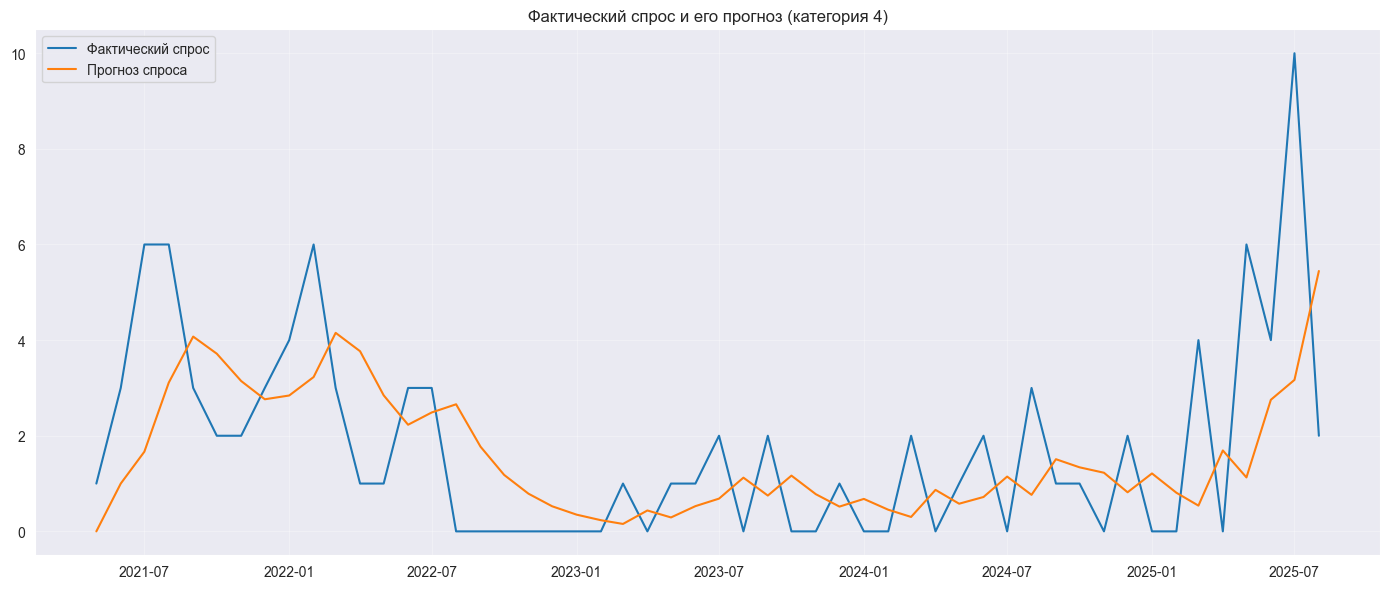

In [398]:
total_df = monthly[['month', 'D_pred', 'D']]
total_df = monthly.groupby(['month']).agg({'D': 'sum', 'D_pred': 'sum'}).reset_index()
x = total_df['month']

if x.dtype == 'object':
    x_dt = pd.to_datetime(x.astype(str) + '-01', errors='coerce')
else:
    try:
        x_dt = x.dt.to_timestamp()
    except Exception:
        x_dt = pd.to_datetime(x, errors='coerce')


plt.figure(figsize=(14, 6))
plt.plot(x_dt, total_df['D'], label='Фактический спрос')
fc = total_df['D_pred']          # или wk_train['fc_ewm_t1']
plt.plot(x_dt, fc, label='Прогноз спроса')

plt.title('Фактический спрос и его прогноз (категория 4)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## ****Моделирование****

In [399]:
monthly_train = monthly[monthly['month'] < '2024-08']
monthly_test = monthly[monthly['month'] >= '2024-08']

**Приведение параметров к месячному эквиваленту**

In [400]:
d = 29
dd = 12

In [401]:
lt_m_list = {k: [max(1, int((x + d) // (d + 1))) for x in v if pd.notna(x)] for k, v in lt_list.items()}
phi_lists = {k: [min(1.0, max(0.0, float(x))) for x in v if pd.notna(x)] for k, v in phi_lists.items()}
lamb = 0.3 / dd # издержки хранения в 30% от стоимости в год
lamd_fine = 5 # издержки дефицита в 500% от стоимости

In [402]:
monthly_train['res_cost'] = lamb * monthly_train['Price']
monthly_train['def_cost'] = lamd_fine * monthly_train['Price']

/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/2703876600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_train['res_cost'] = lamb * monthly_train['Price']
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/2703876600.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_train['def_cost'] = lamd_fine * monthly_train['Price']


## **Запуск подбора**

In [403]:
phi_pool_all = [x for v in phi_lists.values() for x in v]
lt_pool_all = [x for v in lt_m_list.values() for x in v]

def sample_phi_lt_cat(rng):
    phi = float(rng.choice(phi_pool_all))
    L = int(rng.choice(lt_pool_all))
    return phi, L

**Создание сеток**

In [404]:
D_mean = monthly_train['D_pred'].mean()
q_lo = 0.75
q_hi = 0.95
s_lo = float(np.quantile(monthly_train['D_pred'], q_lo))
s_hi = float(np.quantile(monthly_train['D_pred'], q_hi))
s_grid = [float(x) for x in np.geomspace(s_lo, s_hi, 9)]

min_k = 6.0
Delta_grid = [float(k * D_mean) for k in [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0] if k >= min_k]

In [405]:
monthly_train['Price'] = monthly_train['Price'].ffill().bfill()
monthly_train['res_cost'] = lamb * monthly_train['Price']
monthly_train['def_cost'] = lamd_fine * monthly_train['Price']

#D_pool = [x for x in D_pool if pd.notna(x)]
#phi_pool_all = [x for x in phi_pool_all if pd.notna(x)]
#lt_pool_all = [int(x) for x in lt_pool_all if pd.notna(x)]

/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/3007120662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_train['Price'] = monthly_train['Price'].ffill().bfill()
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/3007120662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_train['res_cost'] = lamb * monthly_train['Price']
/var/folders/1r/mbrbj4ls20375m0vmbw3l9dh0000gn/T/ipykernel_64460/3007120662.py:3: SettingWithCopyWarning: 
A value is trying to be set

**Создание итогового фрейма для модели**

In [406]:
train_cat = (monthly_train.groupby('month', as_index=False)
    .agg(
        D=('D', 'sum'),
        A=('A', 'sum'),
        q_base=('q_base', 'sum'),
        amount_base=('amount_base', 'sum'),
        R_end=('R_end', 'sum'),
        R_plus_avg=('R_plus_avg', 'sum'),
        R_minus_avg=('R_minus_avg', 'sum'),
    )
)

train_cat['Price'] = (train_cat['amount_base'] / train_cat['q_base'].replace(0, np.nan)).ffill().bfill()

# начало месяца из баланса
train_cat['R_beg'] = train_cat['R_end'] - train_cat['A'] + train_cat['D']

# издержки на месяц
train_cat['res_cost'] = lamb * train_cat['Price']
train_cat['def_cost'] = lamd_fine * train_cat['Price']

train_cat['D_pred'] = monthly_train['D_pred']

D_pool = train_cat.loc[train_cat['month'] >= pd.Period('2022-06-06', freq=period), 'D'].tolist()

In [407]:
infl = pd.read_excel('/Users/ivanastahov/Downloads/inf_s7.xlsx')
s = infl['Дата'].astype(str).str.replace(',', '.', regex=False).str.strip()
mm = s.str.split('.', n=1, expand=True)[0].astype(int)
yy = s.str.split('.', n=1, expand=True)[1].astype(int)
infl['month_dt'] = pd.to_datetime(yy.astype(str) + '-' + mm.astype(str).str.zfill(2) + '-01', errors='coerce')
infl = infl.dropna(subset=['month_dt']).sort_values('month_dt').reset_index(drop=True)

pi_yoy = infl['Инфляция, % г/г'].astype(float) / 100.0
pi_m = (1.0 + pi_yoy) ** (1.0 / 12.0) - 1.0
cpi = (1.0 + pi_m).cumprod().to_numpy(dtype=float)
base_cpi = float(cpi[-1])

infl_map = infl[['month_dt']].copy()
infl_map['deflator_to_base'] = base_cpi / cpi

train_cat = apply_infl_deflate(train_cat)

/Users/ivanastahov/PyCharmMiscProject/.venv/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


**Обучение модели и сранение с реальностью для категорий 1 и 3**

In [408]:
best, results = grid_search_s_delta(
    df=train_cat,
    D_pool=None,
    s_grid=s_grid,
    Delta_grid=Delta_grid,
    n_sims=500,
    base_seed=1,
    d_mode='forecast',
    demand_col='D_pred',
    # max_shortage_share=0.15,
    objective='mean'
)

best

{'s': 3.79855204999238,
 'S': 22.170236746320576,
 'mean_cost': 653476023.4807931,
 'meadian_cost': 648917610.0275425,
 'p95_cost': 1010055295.2330059,
 'mean_shortage_share': 0.10184615384615384,
 'mean_n_orders': 4.0,
 'Delta': 18.371684696328195}

In [409]:
model_metrics, forecast_tbl = forecast_by_period(
    df=train_cat,
    s=best['s'],
    S=best['S'],
    D_pool=None,
    n_sims=500,
    base_seed=1,
    d_mode='forecast',
    demand_col='D_pred'
)

base_metrics, base_tbl = baseline_costs(train_cat, buy_mode='notamount')
base_metrics, cmp_tbl, main_metrics = compare_real_vs_forecast(train_cat, forecast_tbl, buy_mode='notamount')

In [410]:
main_metrics

{'delta_total': -40589193149.20379,
 'delta_mean': -1040748542.2872766,
 'delta_std': 544606251.1078879,
 'q95_delta': -150938752.2330517,
 'q95_pred_week': 89908065.33297716,
 'q95_real_week': 1957772699.0340633}

**Обучение модели и сранение с реальностью для категорий 0, 2 и 4**

In [411]:
r_grid = s_grid
Q_grid = [float(k * np.mean(train_cat['D'])) for k in [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0]]

In [412]:
# best_rq, results_rq = grid_search_rQ(
#     df=train_cat,
#     D_pool=None,
#     r_grid=r_grid,
#     Q_grid=Q_grid,
#     n_sims=500,
#     base_seed=1,
#     d_mode='forecast',
#     demand_col='D_pred',
#     # max_shortage_share=0.25
# )


In [413]:
# best_rq

In [414]:
# model_rq_metrics, forecast_rq_tbl = forecast_by_period_rQ(
#     df=train_cat,
#     r=best_rq['r'],
#     Q=best_rq['Q'],
#     D_pool=None,
#     n_sims=500,
#     base_seed=1,
#     d_mode='forecast',
#     demand_col='D_pred'
# )
#
# base_metrics, cmp_tbl, main_metrics = compare_real_vs_forecast(train_cat, forecast_rq_tbl, buy_mode='amount')

In [415]:
main_metrics

{'delta_total': -40589193149.20379,
 'delta_mean': -1040748542.2872766,
 'delta_std': 544606251.1078879,
 'q95_delta': -150938752.2330517,
 'q95_pred_week': 89908065.33297716,
 'q95_real_week': 1957772699.0340633}

## **Проверка на test**

In [416]:
test_cat = (monthly_test.groupby('month', as_index=False)
    .agg(
        D=('D', 'sum'),
        A=('A', 'sum'),
        q_base=('q_base', 'sum'),
        amount_base=('amount_base', 'sum'),
        R_end=('R_end', 'sum'),
        R_plus_avg=('R_plus_avg', 'sum'),
        R_minus_avg=('R_minus_avg', 'sum'),
    )
)

test_cat['Price'] = (test_cat['amount_base'] / test_cat['q_base'].replace(0, np.nan)).ffill().bfill()

# начало месяца из баланса
test_cat['R_beg'] = test_cat['R_end'] - test_cat['A'] + test_cat['D']

# издержки на месяц
test_cat['res_cost'] = lamb * test_cat['Price']
test_cat['def_cost'] = lamd_fine * test_cat['Price']

test_cat = pd.merge(monthly_test[['month', 'D_pred']], test_cat, on='month')

D_pool = test_cat.loc[test_cat['month'] >= pd.Period('2022-06-06', freq=period), 'D'].tolist()

**Для sS**

In [417]:
model_metrics_test, forecast_tbl_test = forecast_by_period(
    df=test_cat,
    s=best['s'],
    S=best['S'],
    D_pool=None,
    n_sims=500,
    base_seed=1,
    d_mode='forecast',
    demand_col='D_pred'
)

base_metrics_test, cmp_tbl_test, main_metrics_test = compare_real_vs_forecast(
    test_cat, forecast_tbl_test, buy_mode='notamount'
)

main_metrics_test

{'delta_total': -142239250287.84097,
 'delta_mean': -10941480791.372383,
 'delta_std': 7792173906.307858,
 'q95_delta': -1882341064.318954,
 'q95_pred_week': 7239970411.744921,
 'q95_real_week': 26625120914.45898}

**Для RQ**

In [418]:
# model_rq_metrics, forecast_rq_tbl = forecast_by_period_rQ(
#     df=test_cat,
#     r=best_rq['r'],
#     Q=best_rq['Q'],
#     D_pool=None,
#     n_sims=500,
#     base_seed=1,
#     d_mode='forecast',
#     demand_col='D_pred'
# )
#
# base_metrics, cmp_tbl, main_metrics_test = compare_real_vs_forecast(test_cat, forecast_rq_tbl, buy_mode='notamount')
#
# main_metrics_test

## **Зависимость от лямбд**

In [344]:
# dd = 12
#
# lamb_grid = [0.1/dd, 0.2/dd, 0.3/dd, 0.4/dd, 0.5/dd]
# lamd_fine_grid = [0.5, 1, 2, 3, 4]
#
# delta_total_tbl = pd.DataFrame(index=lamd_fine_grid, columns=lamb_grid, dtype=float)
# delta_mean_tbl  = pd.DataFrame(index=lamd_fine_grid, columns=lamb_grid, dtype=float)
#
# delta_total_tbl_rq = pd.DataFrame(index=lamd_fine_grid, columns=lamb_grid, dtype=float)
# delta_mean_tbl_rq  = pd.DataFrame(index=lamd_fine_grid, columns=lamb_grid, dtype=float)
#
# for lamd_fine in lamd_fine_grid:
#     for lamb in lamb_grid:
#
#         train_cat_tmp = train_cat.copy()
#         train_cat_tmp['res_cost'] = lamb * train_cat_tmp['Price']
#         train_cat_tmp['def_cost'] = lamd_fine * train_cat_tmp['Price']
#
#         test_cat_tmp = test_cat_tmp.copy()
#         test_cat_tmp['res_cost'] = lamb * test_cat_tmp['Price']
#         test_cat_tmp['def_cost'] = lamd_fine * test_cat_tmp['Price']
#
#
#         # best, results = grid_search_s_delta(
#         #     df=train_cat_tmp,
#         #     D_pool=None,
#         #     s_grid=s_grid,
#         #     Delta_grid=Delta_grid,
#         #     n_sims=500,
#         #     base_seed=1,
#         #     d_mode='forecast',
#         #     demand_col='D_pred',
#         #     objective='mean'
#         # )
#         #
#         # model_metrics, forecast_tbl = forecast_by_period(
#         #     df=train_cat_tmp,
#         #     s=best['s'],
#         #     S=best['S'],
#         #     D_pool=None,
#         #     n_sims=500,
#         #     base_seed=1,
#         #     d_mode='forecast',
#         #     demand_col='D_pred'
#         # )
#         #
#         # base_metrics, base_tbl = baseline_costs(train_cat_tmp, buy_mode='notamount')
#         # base_metrics, cmp_tbl, main_metrics = compare_real_vs_forecast(
#         #     train_cat_tmp, forecast_tbl, buy_mode='notamount'
#         # )
#         #
#         # delta_total_tbl.loc[lamd_fine, lamb] = main_metrics['delta_total']
#         # delta_mean_tbl.loc[lamd_fine, lamb]  = main_metrics['delta_mean']
#
#
#
#
#         best_rq, results_rq = grid_search_rQ(
#             df=train_cat_tmp,
#             D_pool=None,
#             r_grid=r_grid,
#             Q_grid=Q_grid,
#             n_sims=500,
#             base_seed=1,
#             d_mode='forecast',
#             demand_col='D_pred',
#             objective='mean',
#             # max_shortage_share=0.15
#         )
#
#         model_metrics_rq, forecast_tbl_rq = forecast_by_period_rQ(
#             df=train_cat_tmp,
#             r=best_rq['r'],
#             Q=best_rq['Q'],
#             D_pool=None,
#             n_sims=500,
#             base_seed=1,
#             d_mode='forecast',
#             demand_col='D_pred'
#         )
#
#         base_metrics_rq, cmp_tbl_rq, main_metrics_rq = compare_real_vs_forecast(
#             train_cat_tmp, forecast_tbl_rq, buy_mode='notamount'
#         )
#
#         delta_total_tbl_rq.loc[lamd_fine, lamb] = main_metrics_rq['delta_total']
#         delta_mean_tbl_rq.loc[lamd_fine, lamb]  = main_metrics_rq['delta_mean']
#
# # delta_total_tbl.index.name = 'lamd_fine'
# # delta_total_tbl.columns.name = 'lamb'
# # delta_mean_tbl.index.name = 'lamd_fine'
# # delta_mean_tbl.columns.name = 'lamb'
#
# delta_total_tbl_rq.index.name = 'lamd_fine'
# delta_total_tbl_rq.columns.name = 'lamb'
# delta_mean_tbl_rq.index.name = 'lamd_fine'
# delta_mean_tbl_rq.columns.name = 'lamb'

In [319]:
delta_total_tbl_rq

lamb,0.008333,0.016667,0.025000,0.033333,0.041667
lamd_fine,,,,,
0.5,-7.664812e+09,-7.696879e+09,-7.728963e+09,-7.761173e+09,-7.793383e+09
1.0,-1.406805e+10,-1.409643e+10,-1.412481e+10,-1.415320e+10,-1.418158e+10
2.0,-2.692878e+10,-2.695716e+10,-2.698554e+10,-2.701393e+10,-2.704231e+10
3.0,-3.978951e+10,-3.981789e+10,-3.984628e+10,-3.987466e+10,-3.990304e+10
4.0,-5.265024e+10,-5.267862e+10,-5.270701e+10,-5.273539e+10,-5.276377e+10


In [320]:
delta_mean_tbl_rq

lamb,0.008333,0.016667,0.025000,0.033333,0.041667
lamd_fine,,,,,
0.5,-1.393602e+08,-1.399432e+08,-1.405266e+08,-1.411122e+08,-1.416979e+08
1.0,-2.557827e+08,-2.562987e+08,-2.568148e+08,-2.573309e+08,-2.578469e+08
2.0,-4.896141e+08,-4.901302e+08,-4.906463e+08,-4.911623e+08,-4.916784e+08
3.0,-7.234456e+08,-7.239617e+08,-7.244777e+08,-7.249938e+08,-7.255099e+08
4.0,-9.572771e+08,-9.577931e+08,-9.583092e+08,-9.588253e+08,-9.593413e+08


## **Выведение прогнозных и реальных результатов**

In [453]:
d_mode_use = 'forecast'
demand_col = 'D_pred'

# cmp_train, model_metrics_train = build_orders_cmp_rQ(train_cat, 'train')
# cmp_test, model_metrics_test = build_orders_cmp_rQ(test_cat, 'test')

cmp_train, model_metrics_train = build_orders_cmp(train_cat, 'train')
cmp_test, model_metrics_test = build_orders_cmp(test_cat, 'test')

orders_all = (pd.concat([cmp_train, cmp_test], ignore_index=True)
    .sort_values('month')
)

cols = [
    'split', 'month',
    'q_base', 'q_mean',
    'q_p50'
    # , 'q_p95', 'q_delta_mean',
    # 'amount_base', 'buy_cost_real', 'buy_cost_mean', 'buy_delta_mean',
    # 'buy_cost_real_price',
    # 'total_cost_mean'
]

# orders_all[cols]

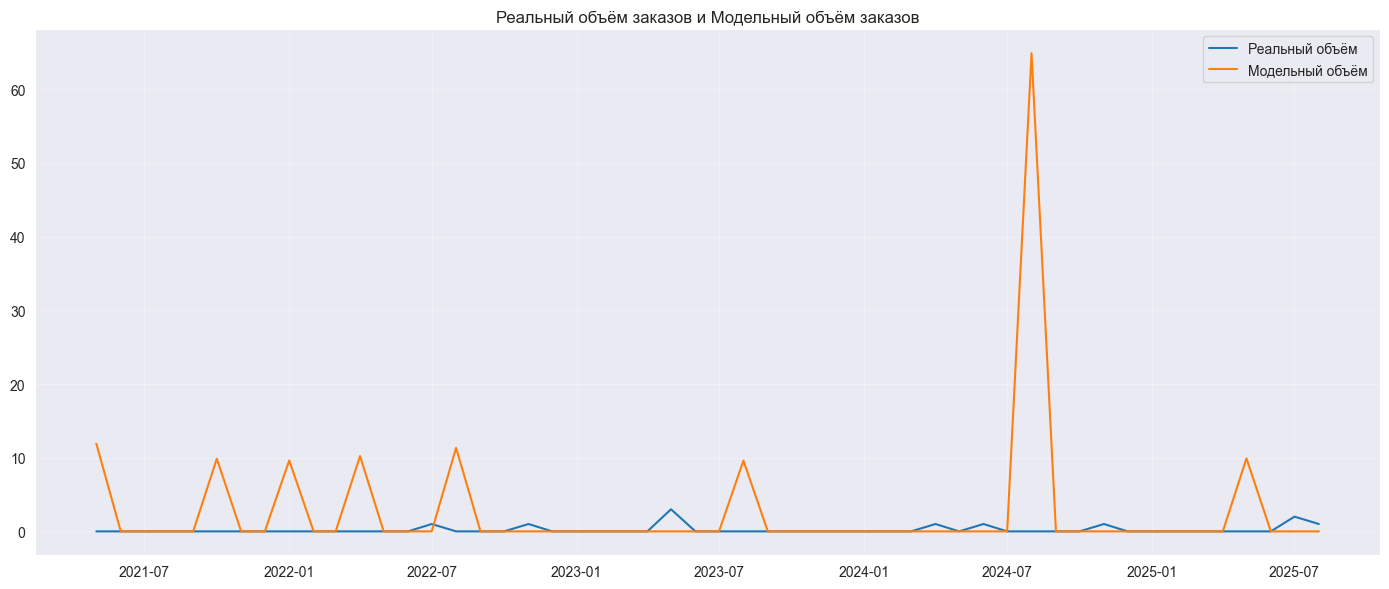

In [448]:
dfp = orders_all.copy()
x = dfp['month']

try:
    x_dt = x.dt.to_timestamp()
except Exception:
    x_dt = pd.to_datetime(x, errors='coerce')

dfp['x_dt'] = x_dt
dfp = dfp.sort_values('x_dt')

plt.figure(figsize=(14, 6))
plt.plot(dfp['x_dt'], dfp['q_base'], label='Реальный объём')
plt.plot(dfp['x_dt'], dfp['q_p50'], label='Модельный объём')

plt.title('Реальный объём заказов и Модельный объём заказов')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [449]:
# pd.DataFrame([best_rq]).to_csv('best_4.csv', index=False)
# pd.DataFrame([main_metrics]).to_csv('main_metrics_4.csv', index=False)
# pd.DataFrame([main_metrics_test]).to_csv('main_metrics_test_4.csv', index=False)
# delta_total_tbl_rq.to_csv('delta_total_tbl_4.csv', index=False)
# delta_mean_tbl_rq.to_csv('delta_mean_tbl_4.csv', index=False)
#
# ord_all = orders_all[cols].copy()
# ord_all.to_csv('total_pred_4.csv', index=False)

## **Прогноз спроса на будущее**

In [452]:
ord_all = orders_all[cols].copy()

In [451]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

tmp = ord_all[['month', 'q_base']].copy()
tmp['month'] = pd.to_datetime(tmp['month'].astype(str) + '-01', errors='coerce')
tmp = tmp.dropna(subset=['month']).sort_values('month')

s = tmp.set_index('month')['q_base'].astype(float)
s = s.groupby(level=0).sum()
s = s.sort_index()

s = s.asfreq('MS')
s = s.interpolate('time')

m = 12
d, D = 1, 1

rows = []
for p in [0,1]:
    for q in [0,1]:
        for P in [0,1]:
            for Q in [0,1]:
                order = (p, d, q)
                sorder = (P, D, Q, m)
                out = fit_model(s, order, sorder, trend='n')
                bad_warn = ('Too few observations' in out['warn']) or ('singular' in out['warn'])
                if out['ok'] and out['converged'] and not bad_warn:
                    rows.append(out)

cand_tbl = pd.DataFrame([{
    'aic': r['aic'],
    'bic': r['bic'],
    'order': r['order'],
    'seasonal_order': r['seasonal_order'],
    'warn': r['warn']
} for r in rows]).sort_values('aic').reset_index(drop=True)

print('TOP by AIC:')
print(cand_tbl.head(1))

TOP by AIC:
         aic        bic      order seasonal_order warn
0  72.596103  77.628489  (1, 1, 1)  (1, 1, 0, 12)     


In [444]:
model = SARIMAX(
    s,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, m),
    trend='n',
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)

ins = res.get_prediction(start=s.index[0], end=s.index[-1], dynamic=False)

ins_tbl = pd.DataFrame({
    'actual': s,
    'fitted': ins.predicted_mean,
    'lo95': ins.conf_int().iloc[:, 0],
    'hi95': ins.conf_int().iloc[:, 1]
})

fc = res.get_forecast(steps=13)

fc_tbl = pd.DataFrame({
    'forecast': fc.predicted_mean,
    'lo95': fc.conf_int().iloc[:, 0],
    'hi95': fc.conf_int().iloc[:, 1]
})

total_pred = pd.concat([ins_tbl, fc_tbl], axis=0)
total_pred['err'] = total_pred['actual'] - total_pred['fitted']
total_pred.head()

,actual,fitted,lo95,hi95,forecast,err
2021-05-01,0.0,0.0,-3394.757202,3394.757202,NaN,0.0
2021-06-01,0.0,0.0,-2771.808036,2771.808036,NaN,0.0
2021-07-01,0.0,0.0,-2771.808468,2771.808468,NaN,0.0
2021-08-01,0.0,0.0,-2771.808468,2771.808468,NaN,0.0
2021-09-01,0.0,0.0,-2771.808468,2771.808468,NaN,0.0


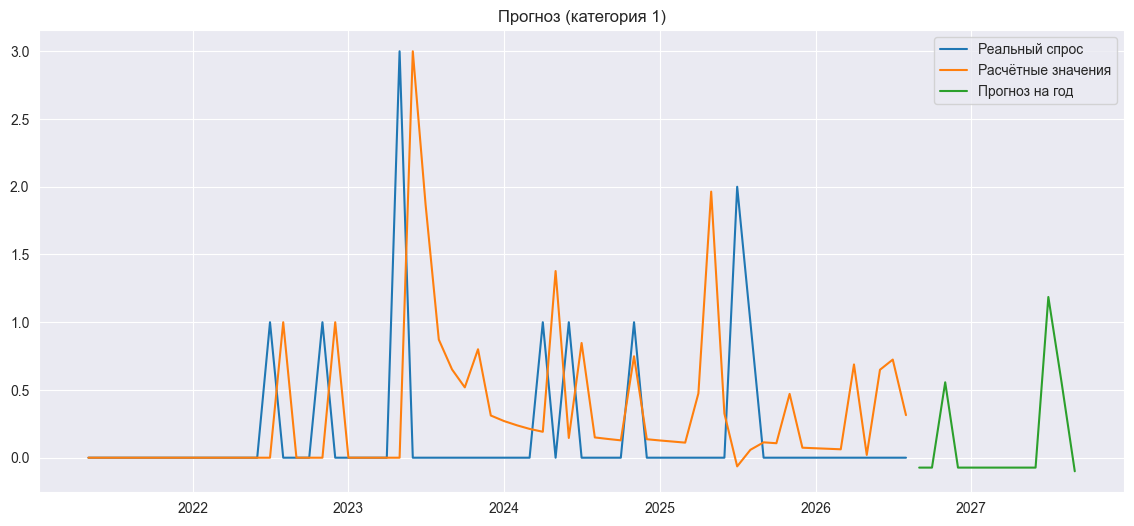

In [446]:
plt.figure(figsize=(14,6))


plt.plot(total_pred['actual'], label='Реальный спрос')
plt.plot(total_pred['fitted'], label='Расчётные значения')
plt.plot(total_pred['forecast'], label='Прогноз на год',)

# plt.fill_between(
#     total_pred.index,
#     total_pred['lo95'],
#     total_pred['hi95'],
#     alpha=0.2
# )

plt.legend()
plt.title('Прогноз (категория 1)')
plt.show()

In [427]:
base_fc = fc_tbl['forecast'].copy()
base_fc = base_fc.iloc[:13]
h = len(base_fc)

rng = np.random.default_rng(42)
err_pool = total_pred['err'][:len(total_pred)-13].dropna().to_numpy(dtype=float)
err_draw = rng.choice(err_pool, size=(500, h), replace=True)
D_sim = base_fc.to_numpy(dtype=float)[None, :] + err_draw
D_sim = np.clip(D_sim, 0.0, None)

D_sim_12 = pd.Series(D_sim.mean(axis=0), index=base_fc.index, name='D_sim')

D_sim_12m = D_sim_12.iloc[:12].copy()
q_pred = D_sim_12m.rename('D').reset_index()
q_pred.columns = ['month', 'D']
q_pred['month'] = pd.to_datetime(q_pred['month']).dt.to_period('M')

monthly_ext = monthly.copy()
monthly_ext['month'] = monthly_ext['month'].astype('period[M]')
monthly_ext = monthly_ext.sort_values('month').reset_index(drop=True)

last_price = float(monthly_ext['Price'].ffill().iloc[-1])

future_ext = pd.DataFrame({
    'month': q_pred['month'],
    'D': q_pred['D'].astype(float),
    'q_base': 0.0,
    'amount_base': 0.0,
    'A': 0.0,
    'Price': last_price,
})

monthly_ext = pd.concat([monthly_ext, future_ext], ignore_index=True, sort=False)
monthly_ext = monthly_ext.sort_values('month').reset_index(drop=True)

monthly_ext['Price'] = monthly_ext['Price'].ffill().bfill()
monthly_ext['res_cost'] = (lamb * monthly_ext['Price']).astype(float)
monthly_ext['def_cost'] = (lamd_fine * monthly_ext['Price']).astype(float)

for c in ['D', 'A', 'q_base', 'amount_base']:
    monthly_ext[c] = monthly_ext[c].fillna(0.0)

R_beg_list = []
R_end_list = []

if 'R_end' in monthly.columns and pd.notna(monthly_ext.loc[0, 'R_end']):
    R_prev = float(monthly_ext.loc[0, 'R_end'])
else:
    R_prev = 0.0

for i in range(len(monthly_ext)):
    D_i = float(monthly_ext.loc[i, 'D']) if pd.notna(monthly_ext.loc[i, 'D']) else 0.0
    A_i = float(monthly_ext.loc[i, 'A']) if pd.notna(monthly_ext.loc[i, 'A']) else 0.0

    R_beg = R_prev
    R_end = R_beg + A_i - D_i

    R_beg_list.append(R_beg)
    R_end_list.append(R_end)
    R_prev = R_end

monthly_ext['R_beg'] = R_beg_list
monthly_ext['R_end'] = R_end_list

monthly_ext['R_plus_beg'] = monthly_ext['R_beg'].clip(lower=0)
monthly_ext['R_minus_beg'] = (-monthly_ext['R_beg']).clip(lower=0)

monthly_ext['R_plus_avg'] = monthly_ext['R_plus_avg'].fillna(monthly_ext['R_end'].clip(lower=0)) if 'R_plus_avg' in monthly_ext.columns else monthly_ext['R_end'].clip(lower=0)
monthly_ext['R_minus_avg'] = monthly_ext['R_minus_avg'].fillna((-monthly_ext['R_end']).clip(lower=0)) if 'R_minus_avg' in monthly_ext.columns else (-monthly_ext['R_end']).clip(lower=0)

if 'OO_end' not in monthly_ext.columns:
    monthly_ext['OO_end'] = 0.0
monthly_ext['OO_end'] = monthly_ext['OO_end'].fillna(0.0)

monthly_ext['Nominal_reserves_end'] = monthly_ext['R_end'] + monthly_ext['OO_end']

monthly_ext['R_plus_end'] = monthly_ext['R_end'].clip(lower=0)
monthly_ext['R_minus_end'] = (-monthly_ext['R_end']).clip(lower=0)

In [428]:
W_MED = 5
W_MEAN = 5
SPAN_EWM = 5
W_WINS_MA = 5
P_LO, P_HI = 0.02, 0.98

wk_train = monthly_ext.dropna(subset=['D']).copy()
if len(wk_train) == 0:
    raise ValueError('D_pool пустой')

wk_train = wk_train.sort_values('month').reset_index(drop=True)
wk_train['D_ewm_causal'] = wk_train['D'].ewm(span=SPAN_EWM, adjust=False).mean()

wk_train['fc_ewm_t1'] = wk_train['D_ewm_causal'].shift(1)
wk_train.loc[0, 'fc_ewm_t1'] = 0.0

wk_train['month_t1'] = wk_train['month'].shift(-1)

t1_forecasts_series = wk_train[['month', 'month_t1', 'D', 'D_ewm_causal', 'fc_ewm_t1']].copy()
# t1_forecasts_series

In [429]:
# Для категории 2
# Q_ALPHA = 0.75

# Для категории 3
Q_ALPHA = 0.5

USE_ONLY_POS_ERR = False
MIN_HIST = 10

t1 = wk_train.sort_values('month').copy()


# ошибка прогноза
t1['e_ewm'] = t1['D'] - t1['fc_ewm_t1']

q_list = []
plan_list = []

for i in range(len(t1)):
    hist = t1.loc[:i-1, 'e_ewm'] if i > 0 else t1['e_ewm'].iloc[0:0]
    hist = hist.dropna()

    if USE_ONLY_POS_ERR:
        hist = hist[hist > 0]

    if len(hist) >= MIN_HIST:
        q_err = float(np.quantile(hist.to_numpy(dtype=float), Q_ALPHA, method='higher'))
    else:
        q_err = 0.0

    q_list.append(q_err)

    fc = t1.loc[i, 'fc_ewm_t1']
    if pd.isna(fc):
        plan_list.append(np.nan)
    else:
        plan_list.append(max(0.0, float(fc) + q_err))

t1['q_err'] = q_list
t1['fc_plan_t1'] = plan_list

t1_plan_quantile = t1[['month', 'D', 'fc_ewm_t1', 'e_ewm', 'q_err', 'fc_plan_t1']].copy()

In [430]:
# Для 2 и 3
# monthly_ext['D_pred'] = t1_plan_quantile['fc_plan_t1']

# Для остальных
monthly_ext['D_pred'] = t1_plan_quantile['fc_ewm_t1']

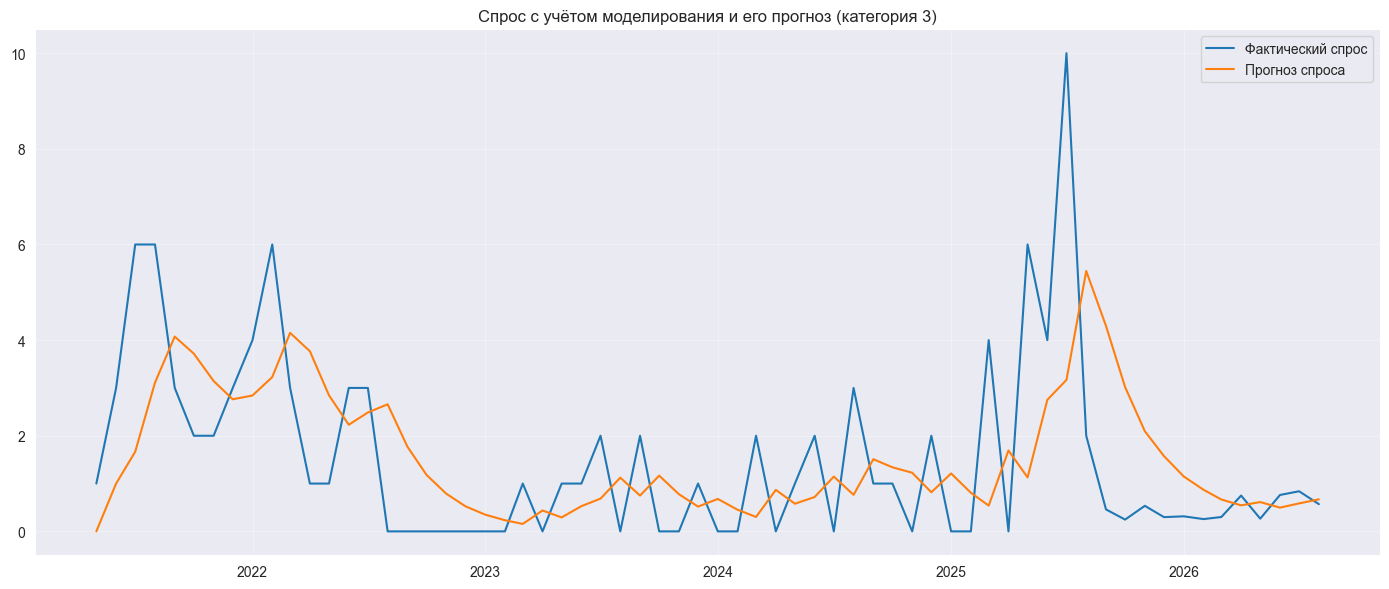

In [431]:
total_df = monthly_ext[['month', 'D_pred', 'D']]
total_df = monthly_ext.groupby(['month']).agg({'D': 'sum', 'D_pred': 'sum'}).reset_index()
x = total_df['month']

if x.dtype == 'object':
    x_dt = pd.to_datetime(x.astype(str) + '-01', errors='coerce')
else:
    try:
        x_dt = x.dt.to_timestamp()
    except Exception:
        x_dt = pd.to_datetime(x, errors='coerce')


plt.figure(figsize=(14, 6))
plt.plot(x_dt, total_df['D'], label='Фактический спрос')
fc = total_df['D_pred']          # или wk_train['fc_ewm_t1']
plt.plot(x_dt, fc, label='Прогноз спроса')

plt.title('Cпрос с учётом моделирования и его прогноз (категория 3)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [432]:
monthly_ext_train = monthly_ext[:len(monthly_ext)-13]
monthly_ext_test = monthly_ext[len(monthly_ext)-13:]

# best_rq, results_rq = grid_search_rQ(
#     df=monthly_ext_train,
#     D_pool=None,
#     r_grid=r_grid,
#     Q_grid=Q_grid,
#     n_sims=500,
#     base_seed=1,
#     d_mode='forecast',
#     demand_col='q_base',
#     # max_shortage_share=0.25
# )
#
#
# model_rq_metrics, forecast_rq_tbl = forecast_by_period_rQ(
#     df=monthly_ext_test,
#     r=best_rq['r'],
#     Q=best_rq['Q'],
#     D_pool=None,
#     n_sims=500,
#     base_seed=1,
#     d_mode='forecast',
#     demand_col='q_base'
# )



best, results = grid_search_s_delta(
    df=monthly_ext_train,
    D_pool=None,
    s_grid=r_grid,
    Delta_grid=Delta_grid,
    n_sims=500,
    base_seed=1,
    d_mode='forecast',
    demand_col='q_base',
    # max_shortage_share=0.25,
    objective='mean'
)



model_metrics_test, forecast_tbl_test = forecast_by_period(
    df=monthly_ext_test,
    s=best['s'],
    S=best['S'],
    D_pool=None,
    n_sims=500,
    base_seed=1,
    d_mode='forecast',
    demand_col='q_base'
)

# base_metrics, cmp_tbl, main_metrics_test = compare_real_vs_forecast(test_cat, forecast_rq_tbl, buy_mode='notamount')

# main_metrics_test

In [433]:
base_metrics, cmp_tbl, main_metrics_test = compare_real_vs_forecast(monthly_ext_test, forecast_tbl_test, buy_mode='notamount')

main_metrics_test

{'delta_total': -279231724924.6604,
 'delta_mean': -21479363455.743107,
 'delta_std': 9354569780.095518,
 'q95_delta': -4050694897.2707624,
 'q95_pred_week': 21590758217.41386,
 'q95_real_week': 26569447521.272797}

In [434]:
d_mode_use = 'forecast'
demand_col = 'D_pred'

# cmp_train, model_metrics_train = build_orders_cmp_rQ(monthly_ext_train, 'train')
# cmp_test, model_metrics_test = build_orders_cmp_rQ(monthly_ext_test, 'test')

cmp_train, model_metrics_train = build_orders_cmp(monthly_ext_train, 'train')
cmp_test, model_metrics_test = build_orders_cmp(monthly_ext_test, 'test')

orders_all = (pd.concat([cmp_train, cmp_test], ignore_index=True)
    .sort_values('month')
)

cols = [
    'split', 'month',
    'q_base', 'q_mean',
    'q_p50'
    # , 'q_p95', 'q_delta_mean',
    # 'amount_base', 'buy_cost_real', 'buy_cost_mean', 'buy_delta_mean',
    # 'buy_cost_real_price',
    # 'total_cost_mean'
]

# orders_all[cols]

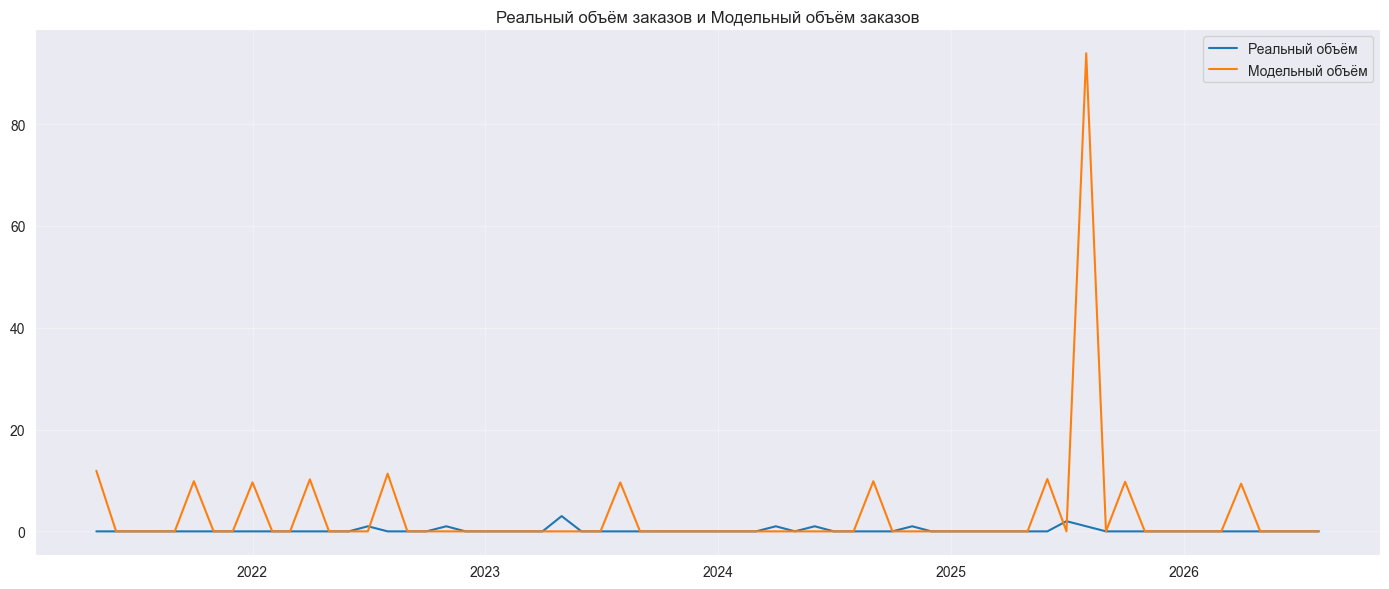

In [435]:
dfp = orders_all.copy()
x = dfp['month']

try:
    x_dt = x.dt.to_timestamp()
except Exception:
    x_dt = pd.to_datetime(x, errors='coerce')

dfp['x_dt'] = x_dt
dfp = dfp.sort_values('x_dt')

plt.figure(figsize=(14, 6))
plt.plot(dfp['x_dt'], dfp['q_base'], label='Реальный объём')
plt.plot(dfp['x_dt'], dfp['q_p50'], label='Модельный объём')

plt.title('Реальный объём заказов и Модельный объём заказов')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [437]:
pd.DataFrame([best]).to_csv('best_pred_1.csv', index=False)
pd.DataFrame([main_metrics]).to_csv('main_metrics_pred_1.csv', index=False)
pd.DataFrame([main_metrics_test]).to_csv('main_metrics_test_pred_1.csv', index=False)

ord_all = orders_all[['split', 'month', 'q_base', 'q_mean']].copy()
ord_all = ord_all.rename(columns={'q_base': 'real', 'q_mean': 'predict'})
ord_all.to_csv('total_year_pred_1.csv', index=False)